<a href="https://colab.research.google.com/github/HMBinara/ML_Project/blob/main/Final_Personal_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#import Libries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
#Load the Files
from google.colab import files
Uploaded = files.upload()

df = pd.read_csv('personal.csv')


Saving personal.csv to personal.csv


In [4]:
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [5]:
df.shape

(80000, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

In [7]:
# 1. Define the input features and the target column
input_features = [
    'social_media_hours', 'netflix_hours', 'exercise_frequency',
    'sleep_hours', 'screen_time', 'age', 'gender',
    'mental_health_rating', 'stress_level'
]
target_col = 'dropout_risk'

# 2. Select only the required columns and create a new DataFrame (others will be dropped)
df_final = df[input_features + [target_col]].copy()

In [8]:
df_final.head()

,social_media_hours,netflix_hours,exercise_frequency,sleep_hours,screen_time,age,gender,mental_health_rating,stress_level,dropout_risk
0,3.0,0.1,3,6.2,10.9,26,Male,6.0,5.8,No
1,0.5,0.4,4,7.2,8.3,28,Male,6.8,5.8,No
2,4.2,0.7,4,9.2,8.0,17,Male,5.7,8.0,No
3,4.6,2.3,3,4.2,11.7,27,Other,8.5,4.6,No
4,0.8,2.7,6,6.5,9.4,25,Female,9.2,5.7,No


In [9]:
df_final.shape

(80000, 10)

In [10]:
#Cheaking the Null Value
df_final.isnull().sum()

,0
social_media_hours,0
netflix_hours,0
exercise_frequency,0
sleep_hours,0
screen_time,0
age,0
gender,0
mental_health_rating,0
stress_level,0
dropout_risk,0


In [11]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   social_media_hours    80000 non-null  float64
 1   netflix_hours         80000 non-null  float64
 2   exercise_frequency    80000 non-null  int64  
 3   sleep_hours           80000 non-null  float64
 4   screen_time           80000 non-null  float64
 5   age                   80000 non-null  int64  
 6   gender                80000 non-null  object 
 7   mental_health_rating  80000 non-null  float64
 8   stress_level          80000 non-null  float64
 9   dropout_risk          80000 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 6.1+ MB


In [12]:
# 1. Initialize LabelEncoders

le = LabelEncoder()

# 2. Convert 'gender' object to numerical format

df_final['gender'] = le.fit_transform(df_final['gender'])
df_final['dropout_risk'] = le.fit_transform(df_final['dropout_risk'])

print("Categorical columns converted to Numerical successfully! ✅")



Categorical columns converted to Numerical successfully! ✅


In [13]:
df_final.head()

,social_media_hours,netflix_hours,exercise_frequency,sleep_hours,screen_time,age,gender,mental_health_rating,stress_level,dropout_risk
0,3.0,0.1,3,6.2,10.9,26,1,6.0,5.8,0
1,0.5,0.4,4,7.2,8.3,28,1,6.8,5.8,0
2,4.2,0.7,4,9.2,8.0,17,1,5.7,8.0,0
3,4.6,2.3,3,4.2,11.7,27,2,8.5,4.6,0
4,0.8,2.7,6,6.5,9.4,25,0,9.2,5.7,0


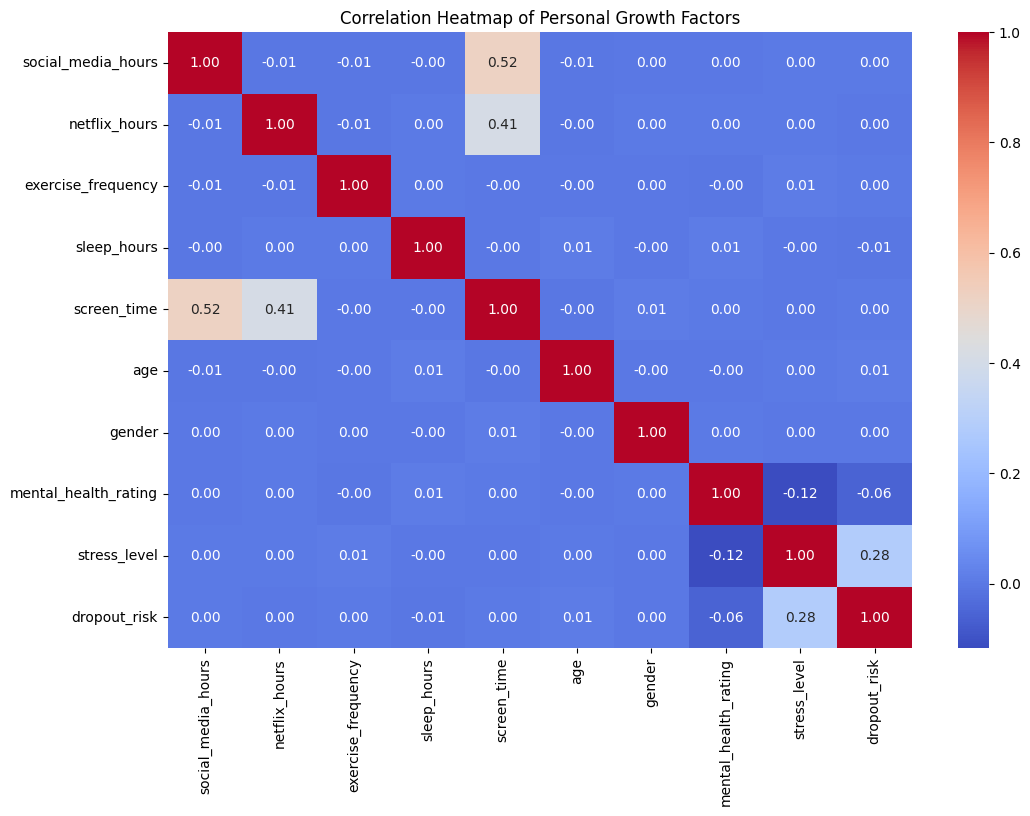

In [14]:
# 1. Heatmap - To see relationships between all features
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Personal Growth Factors')
plt.show()

/tmp/ipykernel_8858/681744494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dropout_risk', data=df_final, palette='viridis')


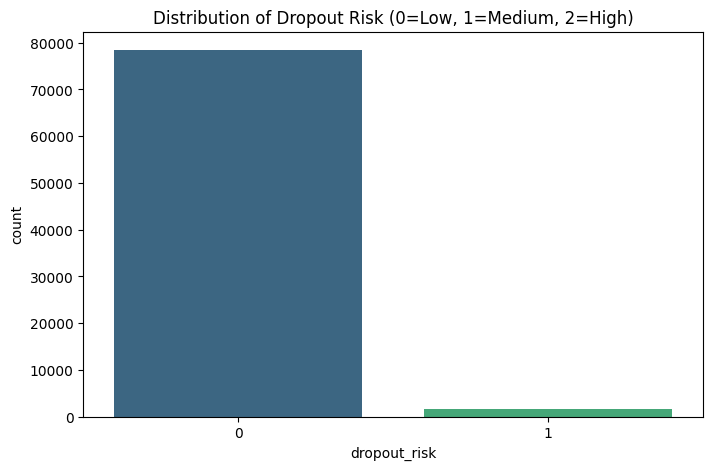

In [15]:
# 2. Target Distribution - To see if the data is balanced
plt.figure(figsize=(8, 5))
sns.countplot(x='dropout_risk', data=df_final, palette='viridis')
plt.title('Distribution of Dropout Risk (0=Low, 1=Medium, 2=High)')
plt.show()

In [16]:
#Spit the Traing Data And Testing Data

X = df_final.drop('dropout_risk', axis=1)
Y = df_final['dropout_risk']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
# 1. Check the current distribution
print(f"Original distribution: {Counter(Y)}")

# 2. Initialize SMOTE
smote = SMOTE(random_state=42)

# 3. Resample the data (අඩු දත්ත ප්‍රමාණය වැඩි කරනවා)
X_resampled, Y_resampled = smote.fit_resample(X, Y)

# 4. Check the new distribution
print(f"Resampled distribution: {Counter(Y_resampled)}")

Original distribution: Counter({0: 78418, 1: 1582})
Resampled distribution: Counter({0: 78418, 1: 78418})


/tmp/ipykernel_8858/3181515383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=Y_resampled, palette='viridis')


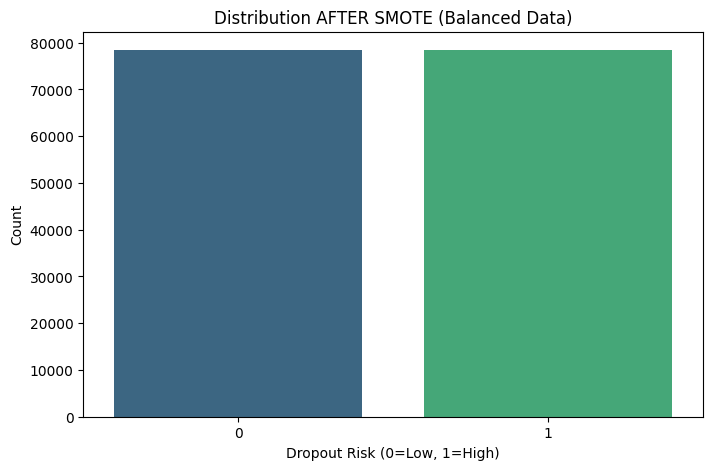

Resampled distribution: Counter({0: 78418, 1: 78418})


In [18]:
# SMOTE එකෙන් පස්සේ ලැබුණු y_resampled එකේ අගයන් බලමු
plt.figure(figsize=(8, 5))
sns.countplot(x=Y_resampled, palette='viridis')
plt.title('Distribution AFTER SMOTE (Balanced Data)')
plt.xlabel('Dropout Risk (0=Low, 1=High)')
plt.ylabel('Count')
plt.show()


from collections import Counter
print(f"Resampled distribution: {Counter(Y_resampled)}")

In [19]:
# Balance කරපු දත්ත ටික Train සහ Test වලට බෙදමු
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (125468, 9)
Testing set size: (31368, 9)


In [20]:
# 1. Train the model using Balanced Data
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, Y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [21]:
Y_pred = model.predict(X_test)
print(f"Accuracy with Balanced Data: {accuracy_score(Y_test, Y_pred):.4f}")

Accuracy with Balanced Data: 0.9831


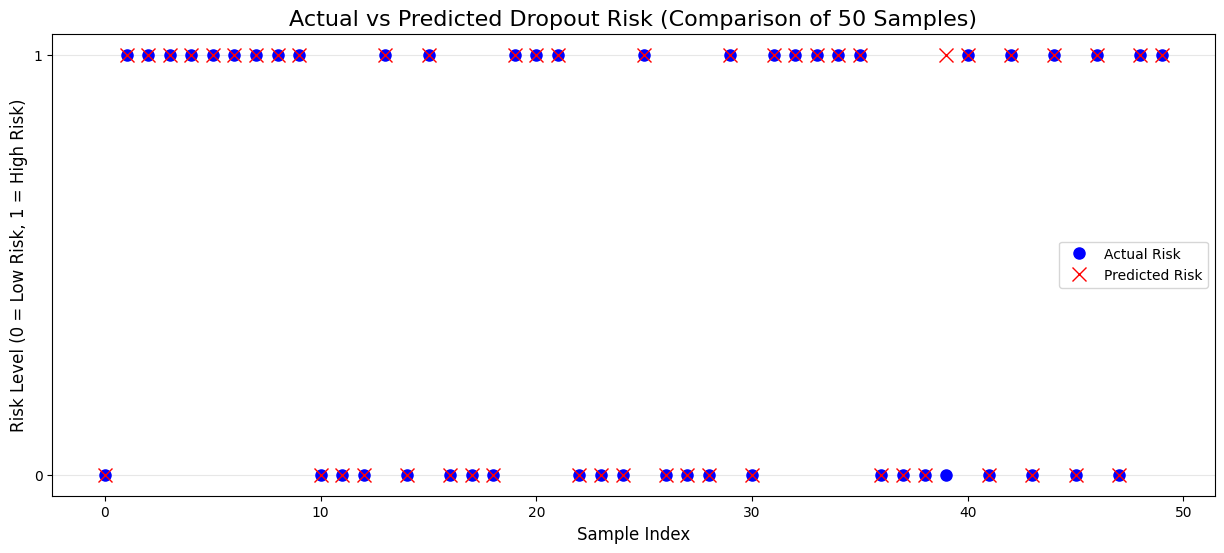

In [22]:
results_df = pd.DataFrame({
    'Actual_Value': Y_test[:50].values,
    'Predicted_Value': Y_pred[:50]
})

# 2. Plotting Actual vs Predicted Values
plt.figure(figsize=(15, 6))

# Plot Actual values as Blue Circles
plt.plot(results_df['Actual_Value'], label='Actual Risk',
         marker='o', linestyle='', color='blue', markersize=8)

# Plot Predicted values as Red X marks
plt.plot(results_df['Predicted_Value'], label='Predicted Risk',
         marker='x', linestyle='', color='red', markersize=10)

plt.title('Actual vs Predicted Dropout Risk (Comparison of 50 Samples)', fontsize=16)
plt.ylabel('Risk Level (0 = Low Risk, 1 = High Risk)', fontsize=12)
plt.xlabel('Sample Index', fontsize=12)
plt.legend(loc='center right')
plt.yticks([0, 1]) # Ensure only 0 and 1 are shown on Y-axis
plt.grid(axis='y', alpha=0.3)
plt.show()

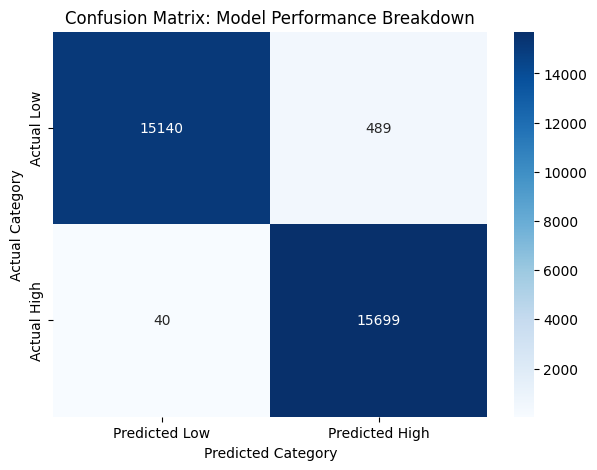

In [23]:
# 3. Generating a Confusion Matrix for the ENTIRE Test Setc
# This shows exactly how many were predicted correctly vs incorrectly
cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.title('Confusion Matrix: Model Performance Breakdown')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

In [24]:
def get_realtime_prediction(user_input_list):
    """
    Takes a list of 9 features and predicts Dropout Probability.
    Input Format: [social_media, netflix, exercise, sleep, screen, age, gender, mental, stress]
    """

    # 1. Convert user input list to a DataFrame with feature names
    user_df = pd.DataFrame([user_input_list], columns=input_features)

    # 2. Get the Final Prediction (0 or 1)
    prediction = model.predict(user_df)[0]

    # 3. Get the Probabilities
    # [0] = Low Risk Probability, [1] = High Risk Probability
    probs = model.predict_proba(user_df)[0]
    high_risk_percent = probs[1] * 100
    low_risk_percent = probs[0] * 100

    # 4. Find the Main Contributing Factor (Feature Importance)
    # Multiplying importance by user values to see what affected them most
    user_impacts = np.array(user_input_list) * model.feature_importances_
    max_impact_idx = np.argmax(user_impacts)
    main_cause = input_features[max_impact_idx].replace('_', ' ').title()

    # --- PRINTING THE OUTPUT ---
    print("\n" + "="*45)
    print("      🎯 REAL-TIME STUDENT RISK REPORT       ")
    print("="*45)

    if prediction == 1:
        print(f"RISK STATUS   : HIGH RISK ⚠️")
        print(f"CONFIDENCE    : {high_risk_percent:.2f}%")
        print(f"MAIN CAUSE    : Your high {main_cause} levels.")
    else:
        print(f"RISK STATUS   : LOW RISK ✅")
        print(f"CONFIDENCE    : {low_risk_percent:.2f}%")
        print(f"ADVICE        : Keep maintaining your current habits!")

    print("="*45)

# --- EXAMPLE USAGE (Testing with actual values) ---
# Replace these values with real user data to test:
# Order: social_media, netflix, exercise, sleep, screen, age, gender (1=M, 0=F), mental, stress
test_user = [5, 3, 1, 4, 9, 23, 1, 4, 8]

get_realtime_prediction(test_user)


      🎯 REAL-TIME STUDENT RISK REPORT       
RISK STATUS   : LOW RISK ✅
CONFIDENCE    : 100.00%
ADVICE        : Keep maintaining your current habits!


In [27]:
import pickle


# 1. Save the Dropout Risk Model
with open('dropout_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 2. Save the Label Encoder (Gender එක encode කරන්න ඕනේ නිසා)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# 3. (Optional) උඹ Productivity Model එකත් හැදුවා නම් ඒකත් මෙහෙම සේව් කරගන්න
with open('prod_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Files saved successfully! Now downloading...")

# 4. Download the files to your PC
files.download('dropout_model.pkl')
files.download('label_encoder.pkl')
# files.download('prod_model.pkl')

Files saved successfully! Now downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>